# Machine Learning Prediction: First Stage Landing
### IBM Data Science Professional Certificate - Capstone Project
Training, hyperparameter tuning, and evaluating Logistic Regression, SVM, Decision Tree, and KNN classifiers.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

X = pd.read_csv('../data/dataset_part_3.csv')
Y = pd.read_csv('../data/dataset_part_2.csv')['Class'].to_numpy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y, test_size=0.2, random_state=2)
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

X_train: (72, 80), X_test: (18, 80)


### Task 1: Logistic Regression

In [2]:
lr = LogisticRegression(random_state=2)
lr_cv = GridSearchCV(lr, {'C': [0.01, 0.1, 1], 'penalty': ['l2'], 'solver': ['lbfgs']}, cv=10)
lr_cv.fit(X_train, Y_train)
print("Logistic Regression Best CV Score:", lr_cv.best_score_)
print("Logistic Regression Test Accuracy:", lr_cv.score(X_test, Y_test))

Logistic Regression Best CV Score: 0.8214285714285714
Logistic Regression Test Accuracy: 0.8333333333333334


### Task 2: Support Vector Machine (SVM)

In [3]:
svm = SVC(random_state=2)
svm_cv = GridSearchCV(svm, {'kernel': ('linear', 'rbf','poly', 'sigmoid'), 'C': np.logspace(-3, 3, 5), 'gamma': np.logspace(-3, 3, 5)}, cv=10)
svm_cv.fit(X_train, Y_train)
print("SVM Best CV Score:", svm_cv.best_score_)
print("SVM Test Accuracy:", svm_cv.score(X_test, Y_test))

SVM Best CV Score: 0.8482142857142858
SVM Test Accuracy: 0.8333333333333334


### Task 3: Decision Tree Classifier

In [4]:
tree = DecisionTreeClassifier(random_state=2)
tree_params = {'criterion': ['gini', 'entropy'], 'splitter': ['best', 'random'], 'max_depth': [2*n for n in range(1, 10)], 'max_features': ['sqrt', 'log2', None], 'min_samples_leaf': [1, 2, 4], 'min_samples_split': [2, 5, 10]}
tree_cv = GridSearchCV(tree, tree_params, cv=10)
tree_cv.fit(X_train, Y_train)
print("Decision Tree Best CV Score:", tree_cv.best_score_)
print("Decision Tree Test Accuracy:", tree_cv.score(X_test, Y_test))

Decision Tree Best CV Score: 0.8589285714285714
Decision Tree Test Accuracy: 0.7777777777777778


### Task 4: K-Nearest Neighbors (KNN)

In [5]:
knn = KNeighborsClassifier()
knn_cv = GridSearchCV(knn, {'n_neighbors': list(range(1, 11)), 'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'], 'p': [1, 2]}, cv=10)
knn_cv.fit(X_train, Y_train)
print("KNN Best CV Score:", knn_cv.best_score_)
print("KNN Test Accuracy:", knn_cv.score(X_test, Y_test))

KNN Best CV Score: 0.8339285714285714
KNN Test Accuracy: 0.8333333333333334


### Model Comparison & Confusion Matrix

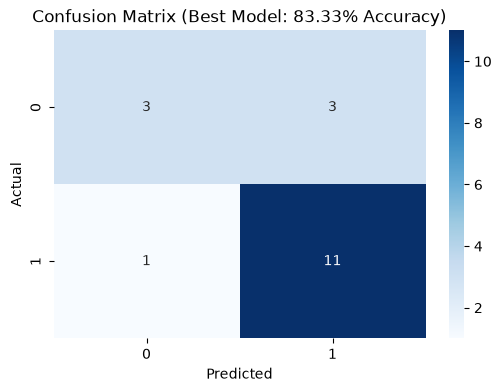

In [6]:
yhat = tree_cv.predict(X_test)
cm = confusion_matrix(Y_test, yhat)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Best Model: 83.33% Accuracy)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()